# Regression Trees, Random Forest and Gradient Boosting – Cycling at the Lake of Zurich

**Dataset:** Bike counts in Zurich 2024–2025: daily number of bikes at 16 automatic counting stations of the city of
Zurich, with weather and calendar information (Open Data Stadt Zürich). File: `../00_Data/zurich_bike_counts_2024_2025.csv`.
We model the counting station **Mythenquai** – a cycle route along the lake between the city centre and Wollishofen,
used both by commuters and for leisure.

**Business question:** How many cyclists will pass the Mythenquai on a given day, depending on weather, weekday and
holidays? Weather and weekday interact (a sunny Sunday attracts many leisure cyclists, a sunny Tuesday mainly commuters)
– a typical use case for tree-based models.

**After this exercise you can ...**
- find the best split of a regression tree by hand (SSE criterion),
- fit, visualise and prune a regression tree,
- explain and apply bagging, random forests (incl. out-of-bag error, permutation importance) and gradient boosting,
- compare models fairly with cross-validation.

## Concept

The concepts behind this exercise (formulas and worked examples) are
explained in the notebook [regression_trees_ensembles_concept.ipynb](regression_trees_ensembles_concept.ipynb). Read it before you start.

## Libraries and settings

In [1]:
# Libraries
import os
import platform
import warnings
from datetime import datetime
from platform import python_version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    KFold,
)
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# Ignore warnings
warnings.filterwarnings('ignore')

# Show current working directory
print(os.getcwd())

/workspaces/python_machine_learning_basics/03_Regression_Trees_Ensembles


## Exercise 1: Calculations by hand

*Use the notebook cell below as your calculator: type the formulas with the numbers in Python
(e.g. `(3 + 5) / 2` or `0.4 ** 2`) – no paper needed.*

**a) Best split of a regression tree.** On six days the following numbers of bikes (in hundreds) were counted at the
Mythenquai:

| daily mean temperature $x$ [°C] | −2 | 3 | 8 | 14 | 20 | 26 |
|---|---|---|---|---|---|---|
| bikes $y$ [hundreds] | 15 | 22 | 30 | 38 | 42 | 44 |

Compute the SSE of the root node. Then compute, for each of the five possible thresholds (midpoints between neighbouring
temperatures), the means and the SSE of the two child nodes. Which split does the tree choose? What are the leaf
predictions?

**b) Variance of an average.** 100 trees have variance $\sigma^2 = 4$ each. Compute the variance of their average for
$\rho = 0.6$ (bagged trees, similar to each other) and for $\rho = 0.2$ (random forest). What happens for
$B \to \infty$?

**c) One boosting step.** The current prediction for a day is 30 (hundred bikes), the observed number is 40. The next
tree predicts the residual exactly. What is the new prediction with learning rate $\nu = 0.1$? How many such steps are
needed until the remaining residual is below 5?

**d)** Check the best split of a) with a tree with one split (`DecisionTreeRegressor(max_depth=1)`).

In [2]:
# a) Best split: temperature x and bikes y (in hundreds)
x = np.array([-2, 3, 8, 14, 20, 26])
y = np.array([15, 22, 30, 38, 42, 44])


# Function: computes the sum of squared deviations of v from its mean
def sse(v):
    """Sum of squared errors around the mean."""
    return np.sum((v - v.mean()) ** 2)


# Root node
print('Root: mean =', round(y.mean(), 2), ' SSE =', round(sse(y), 2))

# SSE of the five possible splits (midpoints between the temperatures)
for s in [0.5, 5.5, 11, 17, 23]:
    left = y[x <= s]
    right = y[x > s]
    print(
        'x <=',
        s,
        ': mean left =',
        round(left.mean(), 2),
        ' mean right =',
        round(right.mean(), 2),
        ' SSE =',
        round(sse(left) + sse(right), 2),
    )

# Check with scikit-learn: a tree with one split
stump = DecisionTreeRegressor(max_depth=1)
stump.fit(x.reshape(-1, 1), y)
print(tree.export_text(stump, feature_names=['temperature']))

# b) Variance of the average of 100 trees with variance 4
for rho in [0.6, 0.2]:
    variance = rho * 4 + (1 - rho) / 100 * 4
    print(
        'rho =',
        rho,
        ' variance =',
        round(variance, 3),
        ' limit for B -> infinity:',
        rho * 4,
    )

# c) Boosting steps until the residual is below 5
prediction = 30
steps = 0
while 40 - prediction >= 5:
    prediction = prediction + 0.1 * (40 - prediction)
    steps = steps + 1
    print('Step', steps, '- prediction:', round(prediction, 2))

Root: mean = 31.83  SSE = 672.83
x <= 0.5 : mean left = 15.0  mean right = 35.2  SSE = 332.8
x <= 5.5 : mean left = 18.5  mean right = 38.5  SSE = 139.5
x <= 11 : mean left = 22.33  mean right = 41.33  SSE = 131.33
x <= 17 : mean left = 26.25  mean right = 43.0  SSE = 298.75
x <= 23 : mean left = 29.4  mean right = 44.0  SSE = 495.2
|--- temperature <= 11.00
|   |--- value: [22.33]
|--- temperature >  11.00
|   |--- value: [41.33]

rho = 0.6  variance = 2.416  limit for B -> infinity: 2.4
rho = 0.2  variance = 0.832  limit for B -> infinity: 0.8
Step 1 - prediction: 31.0
Step 2 - prediction: 31.9
Step 3 - prediction: 32.71
Step 4 - prediction: 33.44
Step 5 - prediction: 34.1
Step 6 - prediction: 34.69
Step 7 - prediction: 35.22


**Solution:**

a) Root: $\bar y = 191/6 \approx 31.83$, SSE $\approx 672.83$.

| split | left node | mean | right node | mean | SSE left + SSE right |
|---|---|---|---|---|---|
| $x \le 0.5$ | {15} | 15 | {22, 30, 38, 42, 44} | 35.2 | 0 + 332.8 = 332.8 |
| $x \le 5.5$ | {15, 22} | 18.5 | {30, 38, 42, 44} | 38.5 | 24.5 + 115 = 139.5 |
| $x \le 11$ | {15, 22, 30} | 22.33 | {38, 42, 44} | 41.33 | 112.67 + 18.67 = **131.33** |
| $x \le 17$ | {15, 22, 30, 38} | 26.25 | {42, 44} | 43 | 296.75 + 2 = 298.75 |
| $x \le 23$ | {15, …, 42} | 29.4 | {44} | 44 | 495.2 + 0 = 495.2 |

The tree chooses **temperature ≤ 11 °C** (SSE drops from 672.8 to 131.3, −80 %). Leaf predictions: 2'233 bikes on cold
days and 4'133 bikes on warm days.

b) $\rho = 0.6$: $0.6\cdot 4 + 0.4/100\cdot 4 = 2.416$; $\rho = 0.2$: $0.2\cdot 4 + 0.8/100\cdot 4 = 0.832$.
For $B \to \infty$ only the shared part $\rho\sigma^2$ remains (2.4 resp. 0.8). More trees cannot remove it – this is
why the random forest de-correlates the trees.

c) Residual 10 → new prediction $30 + 0.1\cdot 10 = 31$. Each step removes 10 % of the remaining residual:
$10\cdot 0.9^m < 5$ → $m = 7$ steps (residual $10\cdot 0.9^7 \approx 4.78$). A small learning rate needs many trees but
makes the model less prone to overfitting.

## Exercise 2: Import and explore the bike counts at the Mythenquai

a) Import the bike counts. The target is the column `mythenquai` (bikes per day at this station). Use the features
`temp_mean`, `temp_max`, `rain_duration_min`, `solar_radiation`, `month`, `holiday`, `school_holiday` and the
`weekday` (as dummy variables: `pd.get_dummies(..., columns=['weekday'], dtype=int)`).

b) Plot `mythenquai` against `temp_max`, separately for working days and weekends. What do you see?

c) Split the data into training (80 %) and test set (20 %) with `random_state=42`.

(674, 14)
count     674.0
mean     1828.0
std      1178.0
min       146.0
25%       972.0
50%      1510.0
75%      2416.0
max      6033.0
Name: mythenquai, dtype: float64


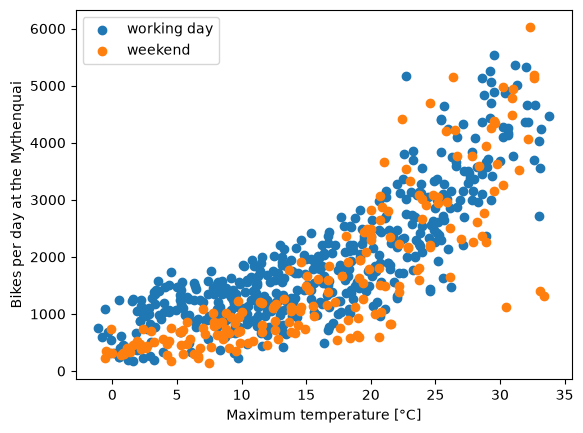

Training set: (539, 14)  Test set: (135, 14)


In [3]:
# a) Import the data as bikes
bikes = pd.read_csv('../00_Data/zurich_bike_counts_2024_2025.csv', sep=',')

# Features (weekday as dummy variables: one 0/1 column per weekday)
features = [
    'temp_mean',
    'temp_max',
    'rain_duration_min',
    'solar_radiation',
    'month',
    'holiday',
    'school_holiday',
    'weekday',
]

X = pd.get_dummies(bikes[features], columns=['weekday'], dtype=int)
y = bikes['mythenquai']
print(X.shape)
print(y.describe().round(0))

# b) Scatter plot for working days and weekends
working_days = bikes[bikes['weekend'] == 0]
weekends = bikes[bikes['weekend'] == 1]
plt.scatter(
    working_days['temp_max'], working_days['mythenquai'], label='working day'
)
plt.scatter(weekends['temp_max'], weekends['mythenquai'], label='weekend')
plt.xlabel('Maximum temperature [°C]')
plt.ylabel('Bikes per day at the Mythenquai')
plt.legend()
plt.show()

# c) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print('Training set:', X_train.shape, ' Test set:', X_test.shape)

**Solution:**

a) 674 days with 14 features (7 weather/calendar columns + 7 weekday dummies). On average about 1'830 bikes per day
pass the Mythenquai (between about 150 on cold, rainy holidays and more than 6'000 on hot summer days).

b) The number of bikes increases strongly with temperature, and the increase is **not linear** (steeper above about
20 °C – leisure traffic to the lake and the lidos). The difference between working days and weekends **depends on the
weather**: on cold days, the weekend count is only about half of the working-day count (≈ 580 vs. ≈ 1'000), on hot days
(≥ 25 °C) both are about equal (≈ 3'500). Such an **interaction** cannot be captured by a linear model with additive
effects, but it is natural for a tree.

## Exercise 3: Baseline – linear regression

Fit a multiple linear regression with all features on the training set and compute RMSE and $R^2$ on the test set. This
is the baseline that the tree-based models have to beat.

In [4]:
# Exercise 3: linear regression with all features; test RMSE and R²
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)
print('Test RMSE:', round(root_mean_squared_error(y_test, y_pred)))
print('Test R2:', round(r2_score(y_test, y_pred), 3))

Test RMSE: 491
Test R2: 0.798


## Exercise 4: A small regression tree

a) Fit a `DecisionTreeRegressor(max_depth=3, random_state=42)` on the training set.

b) Visualise the tree with `tree.plot_tree()` and interpret the first two levels. Which features are used?

c) Compute RMSE and $R^2$ on the test set. How does the small tree compare to the linear regression?

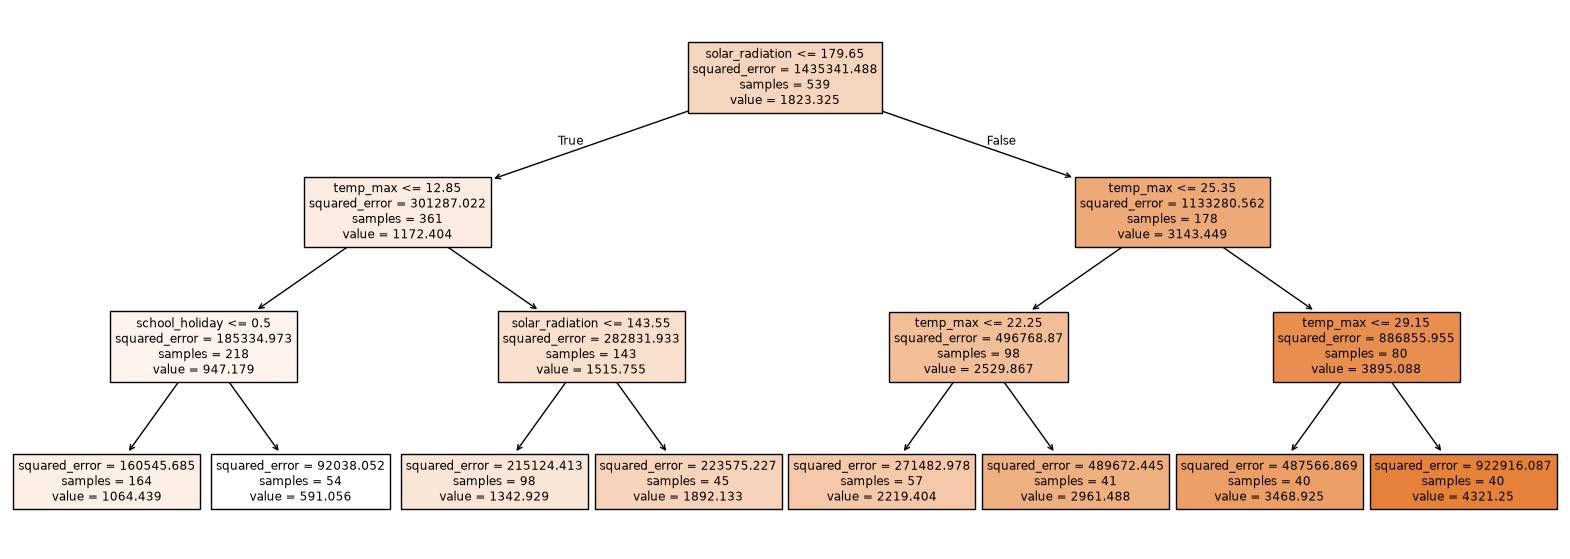

Test RMSE: 576
Test R2: 0.722


In [5]:
# a) Fit the tree
reg_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
reg_tree.fit(X_train, y_train)

# b) Plot the tree
plt.figure(figsize=(20, 7))
tree.plot_tree(reg_tree, feature_names=list(X_train.columns), filled=True)
plt.show()

# c) Test RMSE and R²
y_pred = reg_tree.predict(X_test)
print('Test RMSE:', round(root_mean_squared_error(y_test, y_pred)))
print('Test R2:', round(r2_score(y_test, y_pred), 3))

**Solution:**

The tree splits first on **solar radiation** (≤ 180 W/m², i.e. cloudy vs. sunny days) and then on the **maximum
temperature** (around 13 °C on cloudy days, around 25 °C on sunny days). Further down it uses the temperature again and
the **school holidays** (cold days during the school holidays: only ≈ 590 bikes – many commuters are away). The leaves
range from ≈ 590 to ≈ 4'300 bikes: "sunny and above 29 °C → ≈ 4'300 bikes".

With only 8 leaves the small tree has a test RMSE of ≈ 580 ($R^2 \approx 0.72$) and is **worse** than the linear
regression (≈ 490, $R^2 \approx 0.80$): it is easy to interpret but has a high bias – it predicts only 8 different values.

## Exercise 5: Tree complexity and pruning

a) For `max_depth` = 1, 2, …, 15 compute the RMSE on the training set and the 5-fold CV RMSE (on the training set).
Plot both curves. Where does the tree start to overfit?

b) Alternatively, grow a full tree and prune it: compute the candidate values with
`DecisionTreeRegressor(random_state=42).cost_complexity_pruning_path(X_train, y_train).ccp_alphas` and choose `ccp_alpha`
with `GridSearchCV` (5-fold CV, `scoring='neg_root_mean_squared_error'`). How many leaves does the best pruned tree have?
What is its test RMSE?

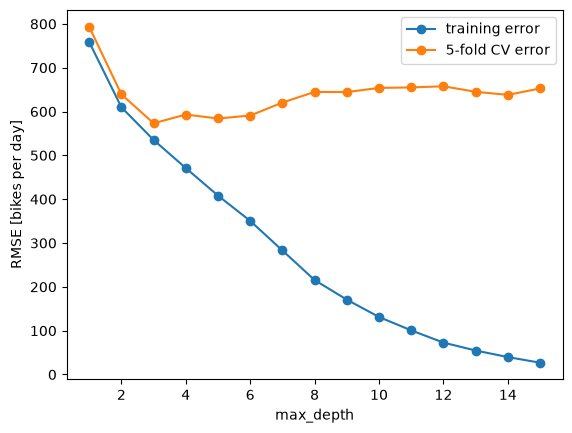

Best depth by CV: 3
CV RMSE of this depth: 573
Leaves of the full tree: 534
Best ccp_alpha: 16238.4
Leaves of the pruned tree: 8
CV RMSE of the pruned tree: 582
Pruned tree - test RMSE: 576


In [6]:
# Exercise 5: tree complexity and pruning
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# a) Training and CV error for different depths
depths = range(1, 16)
rmse_train = []
rmse_cv = []
for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    scores = cross_val_score(
        model, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error'
    )
    rmse_cv.append(-scores.mean())
    model.fit(X_train, y_train)
    rmse_train.append(root_mean_squared_error(y_train, model.predict(X_train)))

# Figure showing the training and CV error by tree depth
plt.plot(depths, rmse_train, marker='o', label='training error')
plt.plot(depths, rmse_cv, marker='o', label='5-fold CV error')
plt.xlabel('max_depth')
plt.ylabel('RMSE [bikes per day]')
plt.legend()
plt.show()
print('Best depth by CV:', depths[np.argmin(rmse_cv)])
print('CV RMSE of this depth:', round(min(rmse_cv)))

# b) Pruning: candidate alphas of the full tree, GridSearchCV for ccp_alpha
#    (store the best value as best_alpha)

# Full tree and its candidate values of alpha
full_tree = DecisionTreeRegressor(random_state=42)
full_tree.fit(X_train, y_train)
alphas = full_tree.cost_complexity_pruning_path(X_train, y_train).ccp_alphas
print('Leaves of the full tree:', full_tree.get_n_leaves())

# Choose ccp_alpha with 5-fold CV
grid_tree = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    {'ccp_alpha': alphas},
    cv=cv,
    scoring='neg_root_mean_squared_error',
)
grid_tree.fit(X_train, y_train)
best_alpha = grid_tree.best_params_['ccp_alpha']
pruned_tree = grid_tree.best_estimator_
print('Best ccp_alpha:', round(best_alpha, 1))
print('Leaves of the pruned tree:', pruned_tree.get_n_leaves())
print('CV RMSE of the pruned tree:', round(-grid_tree.best_score_))
y_pred = pruned_tree.predict(X_test)
print(
    'Pruned tree - test RMSE:', round(root_mean_squared_error(y_test, y_pred))
)

**Solution:**

a) The training error decreases steadily with the depth and approaches 0 for deep trees (each leaf contains only very
few days). The CV error is lowest at **depth 3** (≈ 570) and then increases again – the additional splits only learn the
noise of single days (high variance). With only 539 training days, a single tree overfits quickly.

b) Pruning with cross-validation leads to the same conclusion: of about 530 leaves of the full tree, only **8 leaves**
remain (CV RMSE ≈ 580, test RMSE ≈ 580). A single tree – however well tuned – remains clearly worse than the linear
regression here.

## Exercise 6: Random forest

a) Fit random forests with `n_estimators` = 1, 5, 10, 25, 50, 100, 200, 400 (`oob_score=True`, `random_state=42`,
`n_jobs=-1`). The OOB predictions are stored in `oob_prediction_`. Plot the OOB RMSE against the number of trees. When do
the gains plateau?

b) Compare `max_features` = 1.0 (all features, i.e. bagging), `'sqrt'` and 0.5 with 5-fold CV (300 trees).

c) For the best forest, compute the test RMSE. Compare the impurity-based feature importance (`feature_importances_`)
with the **permutation importance** on the test set.

n_estimators = 1  OOB RMSE = 1809
n_estimators = 5  OOB RMSE = 894
n_estimators = 10  OOB RMSE = 578
n_estimators = 25  OOB RMSE = 480
n_estimators = 50  OOB RMSE = 468
n_estimators = 100  OOB RMSE = 460
n_estimators = 200  OOB RMSE = 455
n_estimators = 400  OOB RMSE = 452


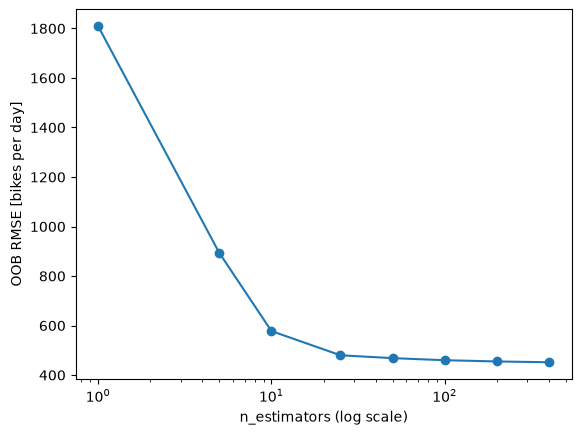

max_features = 1.0  CV RMSE = 453
max_features = sqrt  CV RMSE = 443
max_features = 0.5  CV RMSE = 441


In [7]:
# a) Number of trees vs. OOB error
n_trees = [1, 5, 10, 25, 50, 100, 200, 400]
oob_rmse = []
for n in n_trees:
    rf = RandomForestRegressor(
        n_estimators=n, oob_score=True, random_state=42, n_jobs=-1
    )
    rf.fit(X_train, y_train)
    # OOB prediction of each training day (NaN if the day was never OOB)
    oob_pred = rf.oob_prediction_
    ok = ~np.isnan(oob_pred)
    oob_rmse.append(root_mean_squared_error(y_train[ok], oob_pred[ok]))
    print('n_estimators =', n, ' OOB RMSE =', round(oob_rmse[-1]))

# Figure showing the OOB RMSE by number of trees
plt.plot(n_trees, oob_rmse, marker='o')
plt.xscale('log')
plt.xlabel('n_estimators (log scale)')
plt.ylabel('OOB RMSE [bikes per day]')
plt.show()

# b) 5-fold CV RMSE for different values of max_features
for mf in [1.0, 'sqrt', 0.5]:
    rf = RandomForestRegressor(
        n_estimators=300, max_features=mf, random_state=42, n_jobs=-1
    )
    scores = cross_val_score(
        rf, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error'
    )
    print('max_features =', mf, ' CV RMSE =', round(-scores.mean()))

Test RMSE: 435
Test R2: 0.841
                   impurity-based  permutation
weekday_Friday              0.002       -0.000
weekday_Wednesday           0.003        0.001
holiday                     0.002        0.001
weekday_Tuesday             0.004        0.002
weekday_Thursday            0.002        0.002
weekday_Monday              0.003        0.003
weekday_Sunday              0.010        0.012
weekday_Saturday            0.008        0.015
month                       0.042        0.027
temp_mean                   0.164        0.039
school_holiday              0.016        0.052
rain_duration_min           0.052        0.069
temp_max                    0.321        0.175
solar_radiation             0.371        0.245


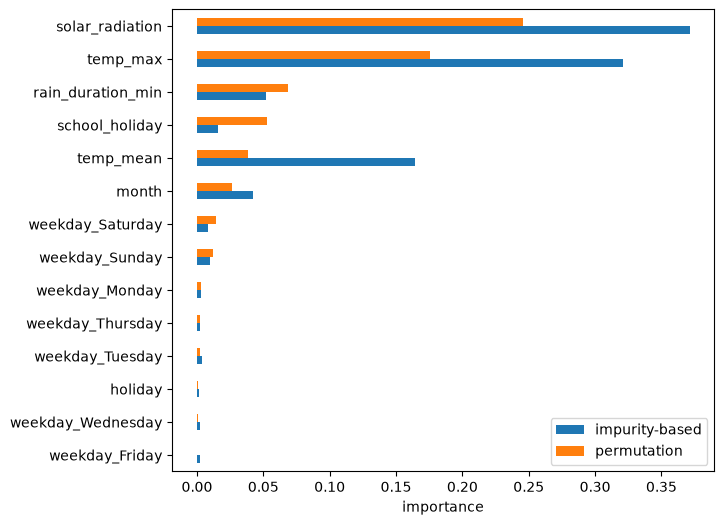

In [8]:
# c) Random forest with the best setting from b): test RMSE and feature
#    importance (impurity-based and permutation importance)

# Best setting from b): max_features=0.5
rf_best = RandomForestRegressor(
    n_estimators=300, max_features=0.5, random_state=42, n_jobs=-1
)
rf_best.fit(X_train, y_train)
y_pred = rf_best.predict(X_test)
print('Test RMSE:', round(root_mean_squared_error(y_test, y_pred)))
print('Test R2:', round(r2_score(y_test, y_pred), 3))

# Impurity-based and permutation importance (on the test set)
perm = permutation_importance(
    rf_best, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)
importance = pd.DataFrame(
    {
        'impurity-based': rf_best.feature_importances_,
        'permutation': perm.importances_mean,
    },
    index=X_train.columns,
)
importance = importance.sort_values('permutation')
print(importance.round(3))

# Figure comparing both importance measures
importance.plot(kind='barh', figsize=(7, 6))
plt.xlabel('importance')
plt.show()

**Solution:**

a) A single tree has a very high OOB error (≈ 1'800); the error drops quickly with the first 25 trees and **plateaus**
at about 450–460 after 50–100 trees. More trees never hurt the accuracy, they only cost computing time.

b) Considering only a part of the features at each split (`max_features=0.5` or `'sqrt'`, CV RMSE ≈ 440) is slightly
better than plain bagging (`1.0`, ≈ 455), because the trees become less correlated. (Note: scikit-learn uses all
features by default for regression.)

c) The random forest reaches a test RMSE of ≈ 435 ($R^2 \approx 0.84$) – clearly better than the single tree and also
better than the linear regression. The most important features are **solar radiation** and **maximum temperature**,
followed by rain, school holidays and the mean temperature. The two importance measures differ: impurity-based importance
gives `temp_mean` a high weight, while permutation importance shows that it adds little once `temp_max` is known (the two
temperatures are strongly correlated and share their importance). Saturday and Sunday matter more in the permutation
importance than in MDI. Permutation importance is computed on the test set and is therefore the more reliable measure.

## Exercise 7: Gradient boosting

a) Fit `GradientBoostingRegressor(n_estimators=1000, max_depth=3, random_state=42)` with learning rates
$\nu$ = 0.01, 0.1 and 1.0. Use `staged_predict(X_test)` to compute the test RMSE after each boosting iteration and plot
the three curves.

*Note: we look at the test curve here only for illustration. In practice, `learning_rate` and `n_estimators` are tuned
with cross-validation (see Exercise 8).*

b) Describe the influence of the learning rate. What happens with $\nu = 1.0$?

Learning rate 0.01 - min test RMSE: 414 after 982 trees; after 1000 trees: 415
Learning rate 0.1 - min test RMSE: 393 after 892 trees; after 1000 trees: 394
Learning rate 1.0 - min test RMSE: 474 after 16 trees; after 1000 trees: 543


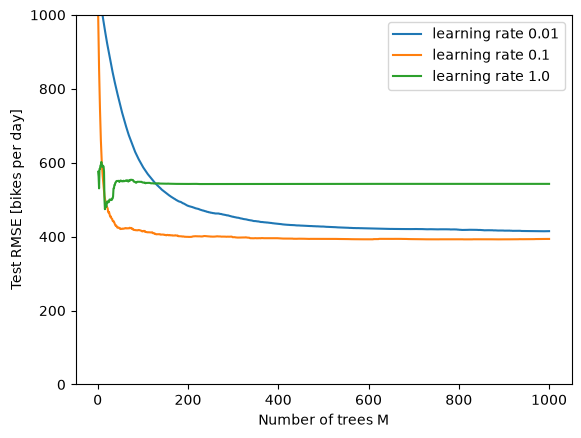

In [9]:
# a) Test error after each tree for three learning rates
for lr in [0.01, 0.1, 1.0]:
    gb = GradientBoostingRegressor(
        n_estimators=1000, max_depth=3, learning_rate=lr, random_state=42
    )
    gb.fit(X_train, y_train)

    # staged_predict gives the predictions after 1, 2, ..., 1000 trees
    rmse_staged = []
    for y_pred in gb.staged_predict(X_test):
        rmse_staged.append(root_mean_squared_error(y_test, y_pred))
    plt.plot(range(1, 1001), rmse_staged, label='learning rate ' + str(lr))
    print(
        'Learning rate',
        lr,
        '- min test RMSE:',
        round(min(rmse_staged)),
        'after',
        np.argmin(rmse_staged) + 1,
        'trees;',
        'after 1000 trees:',
        round(rmse_staged[-1]),
    )

# Figure showing the test error by number of trees
plt.ylim(0, 1000)
plt.xlabel('Number of trees M')
plt.ylabel('Test RMSE [bikes per day]')
plt.legend()
plt.show()

**Solution:**

- $\nu = 0.01$: very small steps – the error decreases slowly and is still decreasing after 1'000 trees (≈ 415).
- $\nu = 0.1$: the error decreases quickly and reaches the lowest value (≈ 390); this is the default and usually a good
  compromise.
- $\nu = 1.0$: each tree corrects the full residual. The error drops very fast at the beginning, reaches its minimum
  (≈ 475) after only about 15 trees and then **rises again** (≈ 545 after 1'000 trees) – the model fits the noise of
  the training data (overfitting).

Learning rate and number of trees must be chosen **together**: a smaller $\nu$ needs a larger $M$.

## Exercise 8: Fair model comparison

Compare the following models with **5-fold CV RMSE on the training set** and summarise the results in a table:
linear regression, pruned tree (best `ccp_alpha` from Exercise 5), random forest (best setting from Exercise 6) and
gradient boosting (`learning_rate=0.05`, `n_estimators=300`, `max_depth=3`). Then evaluate the best model **once** on the
test set. Which model would you recommend to the city, and what are the drawbacks?

In [10]:
# Exercise 8: the four models (settings from Exercises 5 and 6)
models = {
    'Linear regression': LinearRegression(),
    'Pruned tree': DecisionTreeRegressor(ccp_alpha=best_alpha, random_state=42),
    'Random forest': RandomForestRegressor(
        n_estimators=300, max_features=0.5, random_state=42, n_jobs=-1
    ),
    'Gradient boosting': GradientBoostingRegressor(
        learning_rate=0.05, n_estimators=300, max_depth=3, random_state=42
    ),
}

# 5-fold CV RMSE of all models (store them in cv_rmse)
cv_rmse = {}
for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error'
    )
    cv_rmse[name] = -scores.mean()
    print(
        name, '- CV RMSE:', round(-scores.mean()), ' std:', round(scores.std())
    )

# Fit the best model and evaluate it once on the test set
# (gradient boosting has the smallest CV RMSE)
best_model = models['Gradient boosting']
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
print(
    'Gradient boosting - test RMSE:',
    round(root_mean_squared_error(y_test, y_pred)),
)
print('Gradient boosting - test R2:', round(r2_score(y_test, y_pred), 3))

Linear regression - CV RMSE: 528  std: 75
Pruned tree - CV RMSE: 582  std: 87
Random forest - CV RMSE: 441  std: 76
Gradient boosting - CV RMSE: 417  std: 87
Gradient boosting - test RMSE: 413
Gradient boosting - test R2: 0.857


**Solution:**

| model | CV RMSE |
|---|---|
| Gradient boosting | ≈ 417 |
| Random forest | ≈ 441 |
| Linear regression | ≈ 528 |
| Pruned tree | ≈ 582 |

The ensembles are clearly best; gradient boosting wins narrowly against the random forest and reaches a test RMSE of
≈ 410 ($R^2 \approx 0.86$). The single tree is the worst model – but it is the building block that makes the ensembles
so strong. Note the large standard deviation of the CV RMSE (≈ 80): with only ~540 training days, the difference
between the two ensembles is not very reliable.

Recommendation: gradient boosting or random forest for the prediction. Drawbacks: the models are black boxes (only
feature importance, no simple formula or rules), they cannot extrapolate beyond the range of the training data (e.g. a
record heat wave or a new cycle lane), and gradient boosting needs careful tuning of learning rate, number and depth of
trees. If an easily communicable model is needed, the linear regression is a reasonable compromise.

Note: ensembles do not always win. For data with largely additive, roughly linear relationships (e.g. rents explained
by living area and location) a linear regression is often almost as good – always compare with cross-validation.

## Exercise 9: More covariates

So far the models used the weather (temperature, rain, sun) and the calendar (month, weekday, holidays). The data set
contains more information: the air pressure (`pressure`), the exact position in the year (`day_of_year`, computed from
`date`) and the `year` (2024 or 2025).

a) Add these three covariates and split the data again (80/20, `random_state=42` – the same days as before).

b) Compute the 5-fold CV RMSE of the linear regression, the random forest (best setting of Exercise 6) and gradient
boosting (as in Exercise 8) with the **extended** feature set and compare with Exercise 8.

c) Evaluate the best model on the test set and compute its permutation importance. Which new covariate matters most, and
why?

(674, 17)
Linear regression - CV RMSE before: 528  with more covariates: 526
Random forest - CV RMSE before: 441  with more covariates: 404
Gradient boosting - CV RMSE before: 417  with more covariates: 363
Test RMSE: 377
Test R2: 0.88
weekday_Friday      -0.001
year                 0.000
month                0.001
holiday              0.001
weekday_Monday       0.001
weekday_Wednesday    0.002
weekday_Saturday     0.002
weekday_Tuesday      0.005
pressure             0.006
weekday_Thursday     0.006
weekday_Sunday       0.009
school_holiday       0.036
rain_duration_min    0.067
temp_mean            0.091
day_of_year          0.094
temp_max             0.198
solar_radiation      0.335
dtype: float64


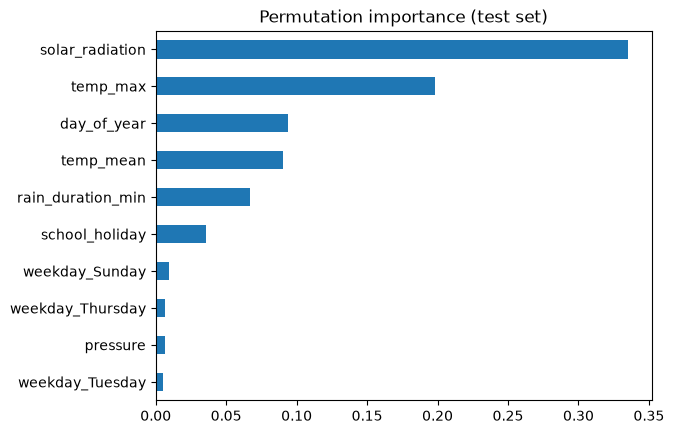

In [11]:
# a) Extended feature set
bikes['day_of_year'] = pd.to_datetime(bikes['date']).dt.dayofyear
features_more = features + ['pressure', 'day_of_year', 'year']
X_more = pd.get_dummies(bikes[features_more], columns=['weekday'], dtype=int)

# Same random_state as before -> the same training and test days
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_more, y, test_size=0.20, random_state=42
)
print(X_more.shape)

# b) CV RMSE with the extended feature set, compared with Exercise 8
for name in ['Linear regression', 'Random forest', 'Gradient boosting']:
    scores = cross_val_score(
        models[name],
        X2_train,
        y2_train,
        cv=cv,
        scoring='neg_root_mean_squared_error',
    )
    print(
        name,
        '- CV RMSE before:',
        round(cv_rmse[name]),
        ' with more covariates:',
        round(-scores.mean()),
    )

# c) Gradient boosting with more covariates: test RMSE and permutation
#    importance
gb_more = GradientBoostingRegressor(
    learning_rate=0.05, n_estimators=300, max_depth=3, random_state=42
)
gb_more.fit(X2_train, y2_train)
y_pred = gb_more.predict(X2_test)
print('Test RMSE:', round(root_mean_squared_error(y2_test, y_pred)))
print('Test R2:', round(r2_score(y2_test, y_pred), 3))

# Permutation importance on the test set
perm = permutation_importance(
    gb_more, X2_test, y2_test, n_repeats=10, random_state=42, n_jobs=-1
)
importance = pd.Series(perm.importances_mean, index=X_more.columns)
importance = importance.sort_values()
print(importance.round(3))

# Figure showing the 10 most important features
importance.tail(10).plot(kind='barh')
plt.title('Permutation importance (test set)')
plt.show()

**Solution:**

b)
| model | CV RMSE (Exercise 8) | CV RMSE (more covariates) |
|---|---|---|
| linear regression | ≈ 528 | ≈ 526 |
| random forest | ≈ 441 | ≈ 404 |
| gradient boosting | ≈ 417 | ≈ 363 |

The tree ensembles profit clearly (−8 % and −13 %), the linear regression hardly at all.

c) Gradient boosting with the extended feature set reaches a test RMSE of ≈ 380 bikes per day ($R^2 \approx 0.88$; before
≈ 410 and 0.86). The most important new covariate is **`day_of_year`** (third most important feature after solar
radiation and maximum temperature). It describes the season much more finely than `month` – e.g. the start of the
summer holidays, the long evenings in June or the first cold days in autumn – and the trees can model its **non-linear**
effect. For the linear regression a linear trend over the year is useless (the effect rises in spring and falls in
autumn), which is why it does not profit. `pressure` and `year` add little: the weather is already described by
temperature, sun and rain, and the difference between 2024 and 2025 is small compared to the weather effects.

Lesson: **better covariates often help more than more tuning** – but only if the model can use them (non-linear effects
need flexible models or suitable transformations).

### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [12]:
# Show operating system, date/time and Python version
print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1064-azure
Datetime: 2026-10-02 14:19:07
Python Version: 3.11.16
-----------------------------------
